In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
words = open('words.txt', 'r').read().splitlines()
words[:8]

['abakus',
 'abandon',
 'abazja',
 'abażur',
 'abażurek',
 'abdukcja',
 'abduktor',
 'abdykacja']

In [4]:
len(words)

48178

In [5]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'r', 18: 's', 19: 't', 20: 'u', 21: 'v', 22: 'w', 23: 'y', 24: 'z', 25: 'ó', 26: 'ą', 27: 'ć', 28: 'ę', 29: 'ł', 30: 'ń', 31: 'ś', 32: 'ź', 33: 'ż', 0: '.'}


In [6]:
# dataset

block_size = 3  # context size
X, Y = [], []

for w in words[:5]:
    print(w)
    context = [0] * block_size

    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context), '---->', itos[ix])
        context = context[1:] + [ix]  # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

abakus
... ----> a
..a ----> b
.ab ----> a
aba ----> k
bak ----> u
aku ----> s
kus ----> .
abandon
... ----> a
..a ----> b
.ab ----> a
aba ----> n
ban ----> d
and ----> o
ndo ----> n
don ----> .
abazja
... ----> a
..a ----> b
.ab ----> a
aba ----> z
baz ----> j
azj ----> a
zja ----> .
abażur
... ----> a
..a ----> b
.ab ----> a
aba ----> ż
baż ----> u
ażu ----> r
żur ----> .
abażurek
... ----> a
..a ----> b
.ab ----> a
aba ----> ż
baż ----> u
ażu ----> r
żur ----> e
ure ----> k
rek ----> .


In [7]:
X.shape

torch.Size([38, 3])

In [8]:
g = torch.Generator().manual_seed(2147483647)

In [9]:
C = torch.randn((34, 2), generator=g)

In [10]:
C

tensor([[ 1.5674, -0.2373],
        [-0.0274, -1.1008],
        [ 0.2859, -0.0296],
        [-1.5471,  0.6049],
        [ 0.0791,  0.9046],
        [-0.4713,  0.7868],
        [-0.3284, -0.4330],
        [ 1.3729,  2.9334],
        [ 1.5618, -1.6261],
        [ 0.6772, -0.8404],
        [ 0.9849, -0.1484],
        [-1.4795,  0.4483],
        [-0.0707,  2.4968],
        [ 2.4448, -0.6701],
        [-1.2199,  0.3031],
        [-1.0725,  0.7276],
        [ 0.0511,  1.3095],
        [-0.8022, -0.8504],
        [-1.8068,  1.2523],
        [-1.2256,  1.2165],
        [-0.9648, -0.2321],
        [-0.3476,  0.3324],
        [-1.3263,  1.1224],
        [ 0.5964,  0.4585],
        [ 0.0540, -1.7400],
        [ 0.1156,  0.8032],
        [-0.8561,  0.5408],
        [ 0.6169,  1.5160],
        [ 0.2472, -0.3777],
        [-1.9081, -0.3717],
        [ 0.1753,  0.9928],
        [-0.6279,  0.0770],
        [-1.9911, -1.3050],
        [-1.3792, -0.3056]])

In [11]:
C[5]

tensor([-0.4713,  0.7868])

In [12]:
F.one_hot(torch.tensor(5), num_classes=34)

tensor([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [13]:
F.one_hot(torch.tensor(5), num_classes=34).float() @ C      # same as ^^ (all the zeros in F.one_hot... cancel values from C except for the 5th row)

tensor([-0.4713,  0.7868])

In [14]:
emb = C[X]
emb.shape

torch.Size([38, 3, 2])

In [15]:
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)

In [16]:
emb.shape, W1.shape     # dimensions don't fit, should be [38,6] and [6, 100]

(torch.Size([38, 3, 2]), torch.Size([6, 100]))

In [17]:
emb = emb.view(-1, 6)   # now okay
emb.shape

torch.Size([38, 6])

In [18]:
h = torch.tanh(emb @ W1 + b1)
h.shape

torch.Size([38, 100])

In [19]:
W2 = torch.randn((100, 34), generator=g)
b2 = torch.randn(34, generator=g)

In [20]:
logits = h @ W2 + b2

In [21]:
logits.shape

torch.Size([38, 34])

In [22]:
counts = logits.exp()

In [23]:
probs = counts / counts.sum(1, keepdim=True)

In [24]:
probs.shape

torch.Size([38, 34])

In [25]:
probs[0].sum()      # sums to 1

tensor(1.0000)

In [26]:
probs[torch.arange(38), Y]

tensor([2.5972e-08, 1.9226e-08, 3.9052e-11, 6.8598e-11, 4.0324e-10, 4.2286e-01,
        6.4735e-13, 2.5972e-08, 1.9226e-08, 3.9052e-11, 7.3672e-07, 1.2764e-10,
        2.7188e-08, 4.1369e-01, 2.7334e-10, 2.5972e-08, 1.9226e-08, 3.9052e-11,
        2.3569e-12, 9.3455e-09, 9.2304e-13, 5.3041e-05, 2.5972e-08, 1.9226e-08,
        3.9052e-11, 1.2172e-07, 6.3278e-08, 6.0942e-05, 2.4163e-09, 2.5972e-08,
        1.9226e-08, 3.9052e-11, 1.2172e-07, 6.3278e-08, 6.0942e-05, 2.7114e-12,
        3.2035e-11, 9.2464e-10])

In [27]:
loss = -probs[torch.arange(38), Y].log().mean()     # inf is i thnk because some of the elements are zero
loss

tensor(18.5749)

In [28]:
loss = F.cross_entropy(logits, Y)   # numerically stable
loss

tensor(18.5749)

### Summary

In [65]:
# dataset

block_size = 3  # context size
X, Y = [], []

for w in words:
    context = [0] * block_size

    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]  # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [66]:
X.shape, Y.shape    # dataset

(torch.Size([500441, 3]), torch.Size([500441]))

In [67]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((34, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.rand(100, generator=g)
W2 = torch.randn((100, 34), generator=g)
b2 = torch.rand(34, generator=g)
parameters = [C, W1, b1, W2, b2]

In [32]:
sum(p.nelement() for p in parameters)

4202

In [33]:
for p in parameters:
    p.requires_grad = True

In [34]:
for _ in range(10):     # long - 4,5s
    #forward pass
    emb = C[X]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y)
    print("loss: ", loss)

    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    #update
    for p in parameters:
        p.data += -0.1 * p.grad

loss:  tensor(18.7329, grad_fn=<NllLossBackward0>)
loss:  tensor(17.7096, grad_fn=<NllLossBackward0>)
loss:  tensor(16.8167, grad_fn=<NllLossBackward0>)
loss:  tensor(16.1090, grad_fn=<NllLossBackward0>)
loss:  tensor(15.4664, grad_fn=<NllLossBackward0>)
loss:  tensor(14.8687, grad_fn=<NllLossBackward0>)
loss:  tensor(14.3087, grad_fn=<NllLossBackward0>)
loss:  tensor(13.7810, grad_fn=<NllLossBackward0>)
loss:  tensor(13.2829, grad_fn=<NllLossBackward0>)
loss:  tensor(12.8146, grad_fn=<NllLossBackward0>)


### minibatches

In [35]:
torch.randint(0, X.shape[0], (32,))

tensor([ 55540, 405637,  52412,  17199, 341040, 336219, 458555, 295460, 468309,
         78691, 380744, 372980, 365050, 252431, 173623, 154404, 185301, 165259,
        479799, 148217, 176866, 255645, 339081, 130471, 496253, 268334, 472321,
        224169, 435214,  83953, 329367, 248050])

In [43]:
C[X[ix]].shape

torch.Size([38, 3, 2])

In [44]:
# C - (vocab_size, embedding_dim)
# X - (N, context_size)
# ix - (batch_size,)

# X[ix] - (batch_size, context_size)
# C[x] - (N, context_size, embedding_dim)
# C[X[ix]] - (batch_size, context_size, embedding_dim)

In [ ]:
for p in parameters:
    p.requires_grad = True

for _ in range(10):     # fast - 0s (with minibatches)
    #construct minibatch
    ix = torch.randint(0, X.shape[0], (32,))

    #forward pass
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])
    print("loss: ", loss)

    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    #update
    for p in parameters:
        p.data += -0.1 * p.grad

loss:  tensor(13.5857, grad_fn=<NllLossBackward0>)
loss:  tensor(8.7368, grad_fn=<NllLossBackward0>)
loss:  tensor(11.8873, grad_fn=<NllLossBackward0>)
loss:  tensor(14.5917, grad_fn=<NllLossBackward0>)
loss:  tensor(13.2867, grad_fn=<NllLossBackward0>)
loss:  tensor(9.0727, grad_fn=<NllLossBackward0>)
loss:  tensor(10.4947, grad_fn=<NllLossBackward0>)
loss:  tensor(10.8340, grad_fn=<NllLossBackward0>)
loss:  tensor(10.4745, grad_fn=<NllLossBackward0>)
loss:  tensor(9.1332, grad_fn=<NllLossBackward0>)


### finding the right learning rate

In [72]:
lre = torch.linspace(-3, 0, 1000)   # learning rate exponent
lrs = 10**lre       # 1000 numbers between 10**(-3)=0.001 and 10**0=1

In [73]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((34, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.rand(100, generator=g)
W2 = torch.randn((100, 34), generator=g)
b2 = torch.rand(34, generator=g)
parameters = [C, W1, b1, W2, b2]

In [ ]:
for p in parameters:
    p.requires_grad = True

lri = []
lossi = []

for i in range(1000):     # fast - 0s (with minibatches)
    #construct minibatch
    ix = torch.randint(0, X.shape[0], (32,))

    #forward pass
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])
    print(loss.item())

    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    #update
    lr = lrs[i]
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    #lri.append(lr)
    lri.append(lre[i])
    lossi.append(loss.item())

print("loss: ", loss.item())

5.694990158081055
6.364192008972168
5.182070732116699
7.2055487632751465
6.177343845367432
6.862310409545898
5.453768253326416
5.258090972900391
4.9613213539123535
5.906148433685303
4.122140884399414
6.588382244110107
5.980014801025391
5.757572174072266
6.093437671661377
4.682590484619141
6.236947536468506
5.6981000900268555
6.397540092468262
5.922028064727783
5.861044406890869
4.337281703948975
5.3032941818237305
5.680434226989746
5.323758125305176
5.198540687561035
6.889967918395996
4.13714599609375
5.041416168212891
6.157227993011475
6.439511775970459
5.347925662994385
5.06482458114624
6.013881206512451
6.381551265716553
4.724241256713867
5.297893524169922
5.323492527008057
6.280087471008301
5.08711576461792
5.39211893081665
5.077713966369629
4.578550815582275
6.109981536865234
6.149420738220215
5.613925933837891
5.099245071411133
4.891714572906494
5.192028045654297
4.904717445373535
4.926670074462891
7.062045574188232
4.890100002288818
5.683553695678711
6.112773895263672
6.04480457

2.6462509632110596
2.365806818008423
2.9141225814819336
2.7978127002716064
3.5959408283233643
2.8867733478546143
2.6818294525146484
2.739316463470459
2.7460830211639404
2.828770399093628
2.6096513271331787
2.7157163619995117
2.8001983165740967
2.8559038639068604
2.8409645557403564
2.8452751636505127
2.609744071960449
3.4461557865142822
3.363694190979004
3.0481231212615967
3.214337110519409
2.901815414428711
2.584934949874878
3.0603175163269043
2.595278024673462
2.7062370777130127
3.1429710388183594
2.9768733978271484
2.8334085941314697
2.628100633621216
3.5915772914886475
3.1483302116394043
2.9399611949920654
2.756995439529419
2.9747586250305176
3.328869104385376
2.732923746109009
2.8801162242889404
2.6581146717071533
2.900280237197876
2.9361608028411865
3.4096410274505615
3.4793338775634766
3.1249725818634033
3.4482691287994385
2.8358914852142334
2.895470380783081
2.7889063358306885
3.1305532455444336
3.4294023513793945
3.4239161014556885
2.453824520111084
3.1435368061065674
3.0831379

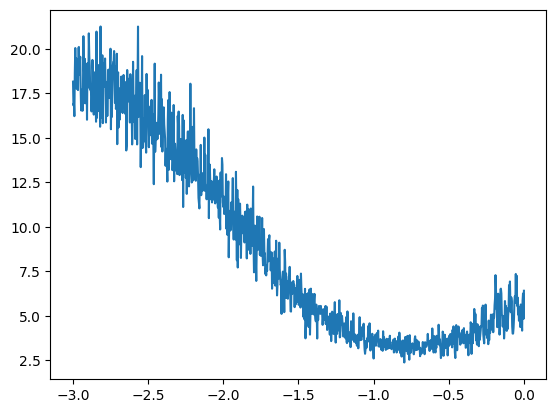

In [75]:
plt.plot(lri, lossi)

the right learning rate is 0.1

In [159]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((34, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.rand(100, generator=g)
W2 = torch.randn((100, 34), generator=g)
b2 = torch.rand(34, generator=g)
parameters = [C, W1, b1, W2, b2]

In [160]:
for p in parameters:
    p.requires_grad = True

for i in range(20000):
    #construct minibatch
    ix = torch.randint(0, X.shape[0], (32,))

    #forward pass
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])

    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    #update
    lr = 0.1
    for p in parameters:
        p.data += -lr * p.grad

print("loss: ", loss.item())

loss:  2.071655035018921


### dataset split

In [98]:
def build_dataset(words):
    block_size = 3  # context size
    X, Y = [], []

    for w in words:
        context = [0] * block_size

        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]  # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

In [99]:
import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

X_train, Y_train = build_dataset(words[:n1])
X_val, Y_val = build_dataset(words[n1:n2])
X_test, Y_test = build_dataset(words[n2:])

torch.Size([400644, 3]) torch.Size([400644])
torch.Size([50015, 3]) torch.Size([50015])
torch.Size([49782, 3]) torch.Size([49782])


### tidy up

In [100]:
X_train.shape, Y_train.shape

(torch.Size([400644, 3]), torch.Size([400644]))

In [131]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((34, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.rand(100, generator=g)
W2 = torch.randn((100, 34), generator=g)
b2 = torch.rand(34, generator=g)
parameters = [C, W1, b1, W2, b2]

In [ ]:
for p in parameters:
    p.requires_grad = True

for i in range(20000):
    #construct minibatch
    ix = torch.randint(0, X_train.shape[0], (32,))

    #forward pass
    emb = C[X_train[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y_train[ix])

    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    #update
    lr = 0.1
    for p in parameters:
        p.data += -lr * p.grad

print("loss: ", loss.item())

loss:  2.1225790977478027


In [ ]:
for i in range(10000):
    #construct minibatch
    ix = torch.randint(0, X_train.shape[0], (32,))

    #forward pass
    emb = C[X_train[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y_train[ix])

    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    #update
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad

print("loss: ", loss.item())

loss:  1.9152315855026245


In [134]:
emb = C[X_val]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y_val)
print("val loss: ", loss)

val loss:  tensor(2.2957, grad_fn=<NllLossBackward0>)


train and val loss are +- the same so we are underfitting, i will make the net bigger

### embeddings visualization

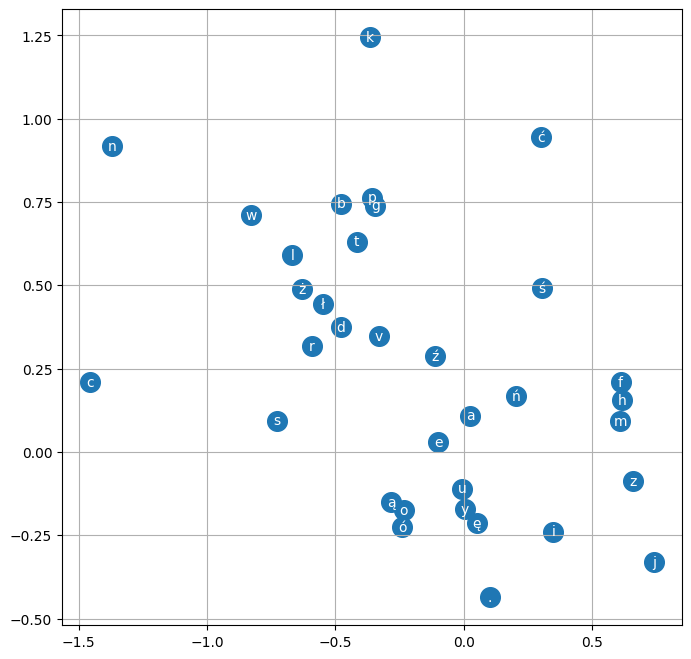

In [135]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color="white")
plt.grid('minor')

vowels are together, . is quite special

### bigger net and batch size

In [161]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((34, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.rand(200, generator=g)
W2 = torch.randn((200, 34), generator=g)
b2 = torch.rand(34, generator=g)
parameters = [C, W1, b1, W2, b2]

In [162]:
sum(p.nelement() for p in parameters)   # number of parameters in total

13374

In [ ]:
for p in parameters:
    p.requires_grad = True

In [164]:
lri = []
lossi = []
stepi = []

In [165]:
for i in range(100000):
    # construct minibatch
    ix = torch.randint(0, X_train.shape[0], (64,))

    # forward pass
    emb = C[X_train[ix]]
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y_train[ix])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 50000 else 0.01
    lr = 0.1
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    stepi.append(i)
    lossi.append(loss.log10().item())


print("loss: ", loss.item())

loss:  2.1856777667999268


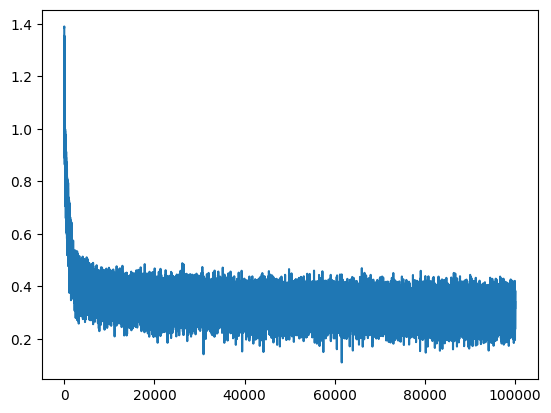

In [166]:
plt.plot(stepi, lossi)

In [167]:
emb = C[X_train]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y_train)
print("train loss: ", loss)

train loss:  tensor(2.0378, grad_fn=<NllLossBackward0>)


In [168]:
emb = C[X_val]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y_val)
print("val loss: ", loss)

val loss:  tensor(2.0540, grad_fn=<NllLossBackward0>)


### bigger context size and 2x more epochs

In [ ]:
def build_dataset(words):
    block_size = 4  # context size
    X, Y = [], []

    for w in words:
        context = [0] * block_size

        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]  # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

In [170]:
import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

X_train, Y_train = build_dataset(words[:n1])
X_val, Y_val = build_dataset(words[n1:n2])
X_test, Y_test = build_dataset(words[n2:])

torch.Size([400840, 4]) torch.Size([400840])
torch.Size([49718, 4]) torch.Size([49718])
torch.Size([49883, 4]) torch.Size([49883])


In [180]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((34, 10), generator=g)
W1 = torch.randn((40, 200), generator=g)
b1 = torch.rand(200, generator=g)
W2 = torch.randn((200, 34), generator=g)
b2 = torch.rand(34, generator=g)
parameters = [C, W1, b1, W2, b2]

In [181]:
for p in parameters:
    p.requires_grad = True

In [ ]:
for i in range(200000):
    # construct minibatch
    ix = torch.randint(0, X_train.shape[0], (64,))

    # forward pass
    emb = C[X_train[ix]]
    h = torch.tanh(emb.view(-1, 40) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y_train[ix])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01
    lr = 0.1
    for p in parameters:
        p.data += -lr * p.grad

In [183]:
emb = C[X_train]
h = torch.tanh(emb.view(-1, 40) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y_train)
print("train loss: ", loss)

train loss:  tensor(2.0167, grad_fn=<NllLossBackward0>)


In [184]:
emb = C[X_val]
h = torch.tanh(emb.view(-1, 40) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y_val)
print("val loss: ", loss)

val loss:  tensor(2.0354, grad_fn=<NllLossBackward0>)


a bit better

### test loss

In [194]:
emb = C[X_test]
h = torch.tanh(emb.view(-1, 40) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y_test)
print("val loss: ", loss)

val loss:  tensor(2.0459, grad_fn=<NllLossBackward0>)


### sampling

In [186]:
block_size = 4

In [193]:
g = torch.Generator().manual_seed(2147483647)

for _ in range(20):
    out = []
    context = [0] * block_size

    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(-1, 40) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))

dojecz.
odlowietanie.
zekka.
pocz.
chypatka.
zatrąk.
ceron.
delcja.
eutyga.
songantal.
eutria.
prosz.
jalunie.
konom.
adsowanie.
telnik.
deryza.
cedlaratut.
zella.
spimietka.
